# Component Classification

CNN over isolated IEEE 315 symbol crops in `component-symbols/`. Structure follows [CircuitNet](https://github.com/aaanthonyyy/CircuitNet)'s classification notebook (`Inspired/circuitnet.md`). The clean val set saturates fast; the number that matters for transfer to real sheets is the *degraded* accuracy at the end.

In [1]:
import sys
sys.path.insert(0, "..")  # modules live one level up from notebooks/

import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from config import DEFAULT_HP, EPOCHS, OUTPUT_DIR
from data import load_datasets
from model import build_geometric, build_model, compile_model, RandomDegrade
from train import callbacks, lr_schedule, setup
from evaluate import predict, most_confused

In [2]:
setup()
hp = DEFAULT_HP  # or json.loads((OUTPUT_DIR / "custom_best_hp.json").read_text()) after tune.py
train_ds, val_ds, class_names, class_weights = load_datasets(mixup_alpha=hp["mixup_alpha"])
len(class_names), int(train_ds.cardinality()), int(val_ds.cardinality())

(40, 260, 65)

## Augmentation preview

Row 1 raw (already MixUp-blended), row 2 geometric jitter, row 3 scan degradation.

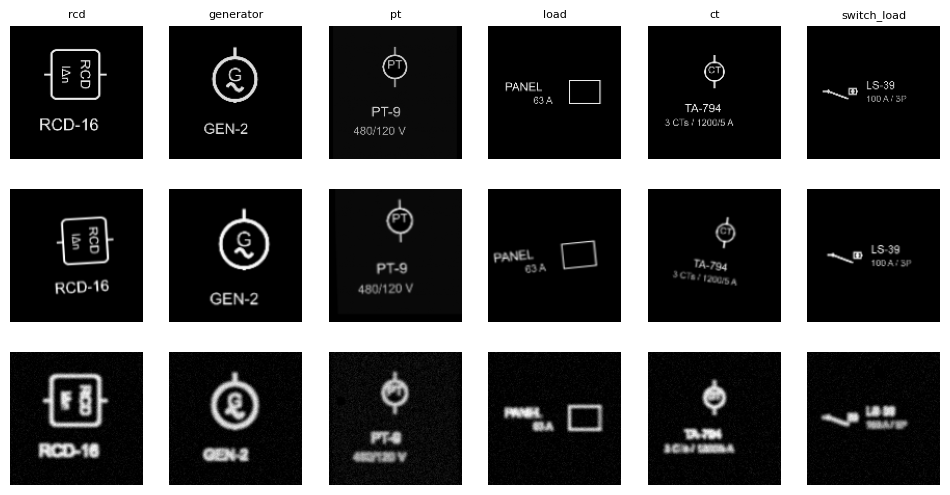

In [3]:
images, labels = next(iter(train_ds))
geometric, degrade = build_geometric(), RandomDegrade()
rows = [images, geometric(images, training=True), degrade(images, training=True)]

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for col in range(6):
    for r, batch in enumerate(rows):
        axes[r, col].imshow(batch[col, ..., 0], cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(class_names[int(np.argmax(labels[col]))], fontsize=8)
for ax in axes.flat:
    ax.axis("off")

## Model

In [4]:
model = build_model(len(class_names), hp)  # backbone="efficientnetv2b0" for the pretrained variant
compile_model(model, lr_schedule(int(train_ds.cardinality()), hp["learning_rate"]), hp)
model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ geometric (Sequential)               │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ degrade (RandomDegrade)              │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_3 (ReLU)                       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,250,632 (4.77 MB)

 Trainable params: 1,248,712 (4.76 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [10]:
tf.debugging.set_log_device_placement(True)

a = tf.random.normal([5000, 5000])
b = tf.random.normal([5000, 5000])
c = tf.matmul(a, b)

print(c.shape)

(5000, 5000)


In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks("notebook"),
)

Epoch 1/150
260/260 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.0578 - loss: 3.6440 - top3: 0.1469 - val_accuracy: 0.0337 - val_loss: 3.8668 - val_top3: 0.1053
Epoch 2/150
260/260 ━━━━━━━━━━━━━━━━━━━━ 602s 2s/step - accuracy: 0.1159 - loss: 3.3621 - top3: 0.2768 - val_accuracy: 0.1255 - val_loss: 3.3482 - val_top3: 0.3168
Epoch 3/150
260/260 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.1529 - loss: 3.2066 - top3: 0.3486 - val_accuracy: 0.1447 - val_loss: 5.0405 - val_top3: 0.2524
Epoch 4/150
260/260 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.2067 - loss: 3.0376 - top3: 0.4227 - val_accuracy: 0.1894 - val_loss: 3.4468 - val_top3: 0.3995
Epoch 5/150
260/260 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - accuracy: 0.2605 - loss: 2.8590 - top3: 0.5285 - val_accuracy: 0.1620 - val_loss: 3.6128 - val_top3: 0.3327
Epoch 6/150
260/260 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step - accuracy: 0.3207 - loss: 2.7044 - top3: 0.5952 - val_accuracy: 0.3163 - val_loss: 2.5325 - val_top3: 0.5976
Epoch 7/150
260/

KeyboardInterrupt: 

## Curves

In [ ]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 4))
for key in ("accuracy", "val_accuracy", "top3", "val_top3"):
    ax_acc.plot(history.history[key], label=key)
for key in ("loss", "val_loss"):
    ax_loss.plot(history.history[key], label=key)
ax_acc.legend()
ax_loss.legend()

## Validation: clean, test-time augmentation, scan-degraded

In [ ]:
results = {mode: predict(model, val_ds, mode) for mode in ("clean", "tta", "degraded")}
{mode: float(np.mean(y == p)) for mode, (y, p) in results.items()}

In [ ]:
labels, predictions = results["degraded"]  # the harder view is where confusions show
disp = ConfusionMatrixDisplay.from_predictions(labels, predictions, display_labels=class_names, xticks_rotation=90)
disp.figure_.set_size_inches(12, 12)

In [ ]:
print(classification_report(labels, predictions, target_names=class_names, zero_division=0))
most_confused(labels, predictions, class_names)

In [ ]:
model.save("../models/notebook.keras")